In [1]:
!pip install prophet xgboost openpyxl

In [2]:
import pandas as pd

df = pd.read_excel("Forecasting Case- Study.xlsx")
df

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages
...,...,...,...,...
8079,Virginia,31-10-2021,255221501.8,Beverages
8080,Washington,31-10-2021,165155956.0,Beverages
8081,West Virginia,31-10-2021,63324231.1,Beverages
8082,Wisconsin,31-10-2021,138373769.4,Beverages


In [3]:
print(df.dtypes)

State        object
Date         object
Total       float64
Category     object
dtype: object


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
print(f"\nMissing values: \n{df.isnull().sum()}")


Missing values: 
State       0
Date        0
Total       0
Category    0
dtype: int64


In [7]:
# ensure correct chronological order within each state
df = df.sort_values(['State', 'Date'])

# take one state sample to inspect time gaps
sample = df[df['State'] == df['State'].iloc[0]]

# check difference between consecutive dates to tells frequency (weekly/daily) + missing gaps
print(sample['Date'].diff().value_counts())

Date
7 days     81
3 days     15
9 days     14
5 days     11
8 days     11
1 days      6
2 days      5
12 days     5
4 days      5
6 days      5
14 days     4
11 days     4
21 days     4
10 days     4
13 days     3
63 days     2
91 days     1
58 days     1
60 days     1
16 days     1
15 days     1
27 days     1
34 days     1
89 days     1
Name: count, dtype: int64


Observation

- The time series is not strictly weekly.
- Date differences vary (1, 3, 5, 9 days etc.).
- This indicates irregular time intervals and missing periods.

Decision

- Resample data to a consistent weekly frequency.
- Aggregate values at weekly level.
- Fill missing periods to ensure continuity.

Reason

- Time series models (ARIMA, Prophet, etc.) require consistent intervals.
- Irregular data can lead to incorrect trend and seasonality learning.

Resample to weekly

In [13]:
# set index for resampling
df = df.set_index('Date')

final_df = []

# process each state separately
for state in df['State'].unique():

    temp = df[df['State'] == state]

    # resample to weekly (take sum of sales in that week)
    temp = temp['Total'].resample('W').mean()

    # fill missing weeks (if any)
    temp = temp.ffill()

    # bring back structure
    temp = temp.reset_index()
    temp['State'] = state

    final_df.append(temp)

df = pd.concat(final_df)

In [14]:
sample = df[df['State'] == df['State'].iloc[0]].sort_values('Date')

# check if all gaps are now weekly
print(sample['Date'].diff().value_counts())

Date
7 days    225
Name: count, dtype: int64


**Feature Engineering**

Machine learning models cannot understand time directly, so temporal patterns are converted into numerical features.

- **Lag features (t-1, t-7, t-30):**
  Capture dependency on past values.

- **Rolling statistics (mean, std):**
  Capture trend and smooth variations.

- **Date feature (month):**
  Capture seasonality patterns.

These features help models like XGBoost and LSTM learn time-based behavior.

In [15]:
# create features per state
df = df.sort_values(['State', 'Date'])

def create_features(temp):
    temp = temp.copy()

    # lag features → past values
    temp['lag_1'] = temp['Total'].shift(1)
    temp['lag_7'] = temp['Total'].shift(7)
    temp['lag_30'] = temp['Total'].shift(30)

    # rolling stats → trend smoothing
    temp['rolling_mean_7'] = temp['Total'].rolling(7).mean()
    temp['rolling_std_7'] = temp['Total'].rolling(7).std()

    # date features → seasonality
    temp['month'] = temp['Date'].dt.month

    return temp

final_df = []

for state in df['State'].unique():
    temp = df[df['State'] == state]
    temp = create_features(temp)
    final_df.append(temp)

df = pd.concat(final_df)

# drop rows with NaN from lag/rolling
df = df.dropna()

In [16]:
print(df.head())
print(df.shape)
print(df.isnull().sum())

         Date        Total    State        lag_1        lag_7       lag_30  \
30 2020-03-08  128066130.9  Alabama          0.0  105904865.6          0.0   
31 2020-03-15  132632134.0  Alabama  128066130.9  106265736.6  108083723.8   
32 2020-03-22  127145065.2  Alabama  132632134.0  108358279.6          0.0   
33 2020-03-29  116657084.0  Alabama  127145065.2  131945461.1          0.0   
34 2020-04-05          0.0  Alabama  116657084.0  107397612.3          0.0   

    rolling_mean_7  rolling_std_7  month  
30    9.854775e+07   4.475518e+07      3  
31    1.023144e+08   4.658509e+07      3  
32    1.049982e+08   4.752304e+07      3  
33    1.028142e+08   4.641663e+07      3  
34    8.747164e+07   6.031724e+07      4  
(8428, 9)
Date              0
Total             0
State             0
lag_1             0
lag_7             0
lag_30            0
rolling_mean_7    0
rolling_std_7     0
month             0
dtype: int64


**Issue in Resampling**

- After resampling, some weeks had `Total = 0`.
- These zeros were not real values but created due to missing data during aggregation.

**Problem**

- Artificial zeros distort the time series.
- Models may interpret this as a sudden drop in sales.
- This negatively impacts trend and seasonality learning.

**Decision**

- Avoid aggregation (`sum` / `mean`) during resampling.
- Use `asfreq()` to introduce missing weeks as NaN.
- Apply forward fill (`ffill()`) to maintain continuity.

**Reason**

- Preserves realistic sales pattern.
- Prevents introduction of false signals.
- Ensures better model performance.

New resampling technique

In [17]:
df = df.set_index('Date')

final_df = []

for state in df['State'].unique():

    temp = df[df['State'] == state]

    # resample WITHOUT aggregation first
    temp = temp['Total'].resample('W').asfreq()

    # now fill missing weeks properly
    temp = temp.ffill()

    temp = temp.reset_index()
    temp['State'] = state

    final_df.append(temp)

df = pd.concat(final_df)

In [18]:
# create features per state
df = df.sort_values(['State', 'Date'])

def create_features(temp):
    temp = temp.copy()

    # lag features → past values
    temp['lag_1'] = temp['Total'].shift(1)
    temp['lag_7'] = temp['Total'].shift(7)
    temp['lag_30'] = temp['Total'].shift(30)

    # rolling stats → trend smoothing
    temp['rolling_mean_7'] = temp['Total'].rolling(7).mean()
    temp['rolling_std_7'] = temp['Total'].rolling(7).std()

    # date features → seasonality
    temp['month'] = temp['Date'].dt.month

    return temp

final_df = []

for state in df['State'].unique():
    temp = df[df['State'] == state]
    temp = create_features(temp)
    final_df.append(temp)

df = pd.concat(final_df)

# drop rows with NaN from lag/rolling
df = df.dropna()

In [19]:
print(df.head())
print(df.shape)
print(df.isnull().sum())

         Date        Total    State        lag_1        lag_7       lag_30  \
30 2020-10-04          0.0  Alabama  127614100.1  258783177.5  128066130.9   
31 2020-10-11  127906087.0  Alabama          0.0  131642694.8  132632134.0   
32 2020-10-18  122464549.6  Alabama  127906087.0  128713002.0  127145065.2   
33 2020-10-25  121301024.5  Alabama  122464549.6  109022481.6  116657084.0   
34 2020-11-01          0.0  Alabama  121301024.5  272214323.0          0.0   

    rolling_mean_7  rolling_std_7  month  
30    1.283266e+08   7.911622e+07     10  
31    1.277928e+08   7.910273e+07     10  
32    1.269001e+08   7.912586e+07     10  
33    1.286542e+08   7.879892e+07     10  
34    8.976643e+07   6.138974e+07     11  
(7138, 9)
Date              0
Total             0
State             0
lag_1             0
lag_7             0
lag_30            0
rolling_mean_7    0
rolling_std_7     0
month             0
dtype: int64


**Issue in Data Values**

- Some records have `Total = 0`.
- These values are not consistent with surrounding data and appear artificial.

**Problem**

- Zero values introduce false drops in the time series.
- Models may misinterpret this as sudden demand collapse.
- This negatively impacts trend and forecasting accuracy.

In [20]:
# count zeros
print("Zero count:", (df['Total'] == 0).sum())

# see some zero rows
print(df[df['Total'] == 0].head(10))

Zero count: 2021
          Date  Total    State        lag_1        lag_7       lag_30  \
30  2020-10-04    0.0  Alabama  127614100.1  258783177.5  128066130.9   
34  2020-11-01    0.0  Alabama  121301024.5  272214323.0          0.0   
35  2020-11-08    0.0  Alabama          0.0  129079259.8  133713630.0   
43  2021-01-03    0.0  Alabama  115522663.3  246158028.2          0.0   
60  2021-05-02    0.0  Alabama  127348327.7  347176075.3          0.0   
73  2021-08-01    0.0  Alabama  143718288.1  137083191.8          0.0   
79  2021-09-12    0.0  Alabama  136554063.7  143718288.1  115644582.4   
91  2021-12-05    0.0  Alabama  177133617.3  195850754.5  148892733.6   
95  2022-01-02    0.0  Alabama  183210806.4  184911321.4  140893518.3   
108 2022-04-03    0.0  Alabama  195635388.9  399817589.1  136554063.7   

     rolling_mean_7  rolling_std_7  month  
30     1.283266e+08   7.911622e+07     10  
34     8.976643e+07   6.138974e+07     11  
35     7.132654e+07   6.676389e+07     11  
43 

**Missing Value Handling**

- Zero values were treated as missing.
- Forward fill was applied per state to preserve continuity, as it preserves realistic sales trends without introducing artificial patterns.

In [21]:
df['Total'] = df['Total'].replace(0, pd.NA)
df['Total'] = df.groupby('State')['Total'].ffill()

In [22]:
# check if any 0 still exists
print((df['Total'] == 0).sum())

# check min value
print(df['Total'].min())

0
10635882.5


**Train-Validation Split Check**
- Verified that training data ends before validation data begins.
- Condition followed:
  
  Train last date < Validation first date

**Reason**

- Prevents data leakage.
- Ensures model does not see future data during training.
- Guarantees realistic and reliable evaluation of model performance.

In [39]:
# splitting the data

train_list = []
val_list = []

for state in df['State'].unique():

    temp = df[df['State'] == state].sort_values('Date')

    train = temp.iloc[:-8]
    val = temp.iloc[-8:]

    train_list.append(train)
    val_list.append(val)

train_df = pd.concat(train_list)
val_df = pd.concat(val_list)

In [25]:
state = df['State'].iloc[0]

train_sample = train_df[train_df['State'] == state]
val_sample = val_df[val_df['State'] == state]

print(train_sample['Date'].max())
print(val_sample['Date'].min())

2023-10-08 00:00:00
2023-10-15 00:00:00


no overlap == no leakage

**SARIMA**

In [26]:
!pip install statsmodels

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

In [28]:
results = []

In [38]:
train['Total'] = pd.to_numeric(train['Total'], errors='coerce')
val['Total'] = pd.to_numeric(val['Total'], errors='coerce')
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

In [32]:
print(train['Total'].isnull().sum())
print(val['Total'].isnull().sum())

1
0


In [35]:
train['Total'] = train['Total'].ffill().bfill()

In [36]:
print(train['Total'].isnull().sum())

0


In [45]:
for state in train_df['State'].unique():

    # get data per state
    train = train_df[train_df['State'] == state].sort_values('Date')
    val = val_df[val_df['State'] == state].sort_values('Date')

    # set proper datetime index
    train = train.set_index('Date')
    val = val.set_index('Date')

    # force weekly frequency (important for SARIMA)
    train.index = pd.DatetimeIndex(train.index, freq='W')
    val.index = pd.DatetimeIndex(val.index, freq='W')

    # target variable
    y_train = train['Total']
    y_val = val['Total']

    # SARIMA model → trend + seasonality
    model = SARIMAX(
        y_train,                     # time series data (sales)

        order=(1,1,1),              # (p,d,q)
                                    # p → autoregression (Current value depends on past values)
                                    # d → differencing (Removes trend by subtracting previous value)
                                    # q → moving average (Current value depends on past errors)

        seasonal_order=(1,1,1,52),  # (P,D,Q,s)
                                    # P → seasonal autoregression
                                    # D → seasonal differencing
                                    # Q → seasonal moving average
                                    # s → seasonal period (Pattern repeats every 52 weeks (1 year))

        enforce_stationarity=False, # allows model to handle non-stationary data
                                    # (real-world data often not perfectly stable)

        enforce_invertibility=False # relaxes constraint on MA part
                                    # helps model fit complex real data
    )

    # train
    model_fit = model.fit(disp=False)

    # forecast next 8 weeks
    forecast = model_fit.forecast(steps=8)

    # evaluate
    rmse = np.sqrt(mean_squared_error(y_val, forecast))

    # store results
    results.append({
        "State": state,
        "Model": "SARIMA",
        "RMSE": rmse
    })

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

**Observations from Model Training**

- Warnings observed related to unsupported index and prediction indexing.
- Some states showed warnings about insufficient data for seasonal parameter estimation.

**Interpretation**

- The model was not recognizing the Date column as a proper time index.
- Forecast outputs were not aligned with datetime.
- Seasonal components may be less reliable for states with limited data.

**Action Taken**

- Set `Date` as the index before training.
- Applied consistent weekly frequency using `asfreq('W')`.

**Reason**

- Ensures the model correctly understands temporal structure.
- Aligns forecasts with actual dates.
- Reduces warnings and improves model reliability.

**Outcome**

- Cleaner training process.
- Improved interpretability of forecasts.
- Better alignment with time series modeling best practices.

In [41]:
# set proper datetime index (required for SARIMA)
train = train.set_index('Date')
val = val.set_index('Date')

# ensure weekly frequency
train = train.asfreq('W')
val = val.asfreq('W')

In [42]:
y_train = train['Total']
y_val = val['Total']

now after preprocessing, I'm running **SARIMA model** once again

**Prophet model**

In [46]:
!pip install prophet

In [49]:
from prophet import Prophet

for state in train_df['State'].unique():

    # get data per state
    train = train_df[train_df['State'] == state].sort_values('Date')
    val = val_df[val_df['State'] == state].sort_values('Date')

    # rename columns → Prophet requires 'ds' (date) and 'y' (target)
    train_p = train[['Date', 'Total']].rename(columns={'Date': 'ds', 'Total': 'y'})
    val_p = val[['Date', 'Total']].rename(columns={'Date': 'ds', 'Total': 'y'})

    # initialize model → handles trend + seasonality automatically
    model = Prophet(weekly_seasonality=True, yearly_seasonality=True)

    # train model
    model.fit(train_p)

    # create future dates (next 8 weeks)
    future = model.make_future_dataframe(periods=8, freq='W')

    # forecast
    forecast = model.predict(future)

    # take only predicted 8 weeks
    y_pred = forecast.tail(8)['yhat'].values
    y_true = val_p['y'].values

    # evaluate
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # store result in SAME list
    results.append({
        "State": state,
        "Model": "Prophet",
        "RMSE": rmse
    })

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**XGBoost model**

In [50]:
!pip install xgboost

from xgboost import XGBRegressor

In [51]:
features = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'month']

In [54]:
for state in train_df['State'].unique():

    # get data
    train = train_df[train_df['State'] == state]
    val = val_df[val_df['State'] == state]

    # clean data FIRST (before splitting X, y)
    train = train.replace([np.inf, -np.inf], np.nan).dropna()
    val = val.replace([np.inf, -np.inf], np.nan).dropna()

    # skip if no data left
    if len(train) == 0 or len(val) == 0:
        continue

    # now create features
    X_train = train[features]
    y_train = train['Total']

    X_val = val[features]
    y_val = val['Total']

    # model
    model = XGBRegressor(
        n_estimators=100,     # number of trees
        learning_rate=0.1,    # learning speed
        max_depth=5,          # tree complexity
        random_state=42
    )

    # train
    model.fit(X_train, y_train)

    # predict
    y_pred = model.predict(X_val)

    # evaluate
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    # store result
    results.append({
        "State": state,
        "Model": "XGBoost",
        "RMSE": rmse
    })

**LSTM model**

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler

In [59]:
for state in train_df['State'].unique():

    # get data
    train = train_df[train_df['State'] == state].sort_values('Date')
    val = val_df[val_df['State'] == state].sort_values('Date')

    # clean data (important)
    train = train.replace([np.inf, -np.inf], np.nan).dropna()
    val = val.replace([np.inf, -np.inf], np.nan).dropna()

    # skip if not enough data
    if len(train) < 15 or len(val) == 0:
        continue

    # use only target
    train_series = train['Total'].values.reshape(-1,1)
    val_series = val['Total'].values.reshape(-1,1)

    # scale
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_series)

    # create sequences (last 10 → next)
    X_train, y_train = [], []

    for i in range(10, len(train_scaled)):
        X_train.append(train_scaled[i-10:i])
        y_train.append(train_scaled[i])

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # skip if sequence not formed
    if len(X_train) == 0:
        continue

    # model (fixed warning)
    model = Sequential([
        Input(shape=(X_train.shape[1], 1)),
        LSTM(50, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # train
    model.fit(X_train, y_train, epochs=10, verbose=0)

    # forecasting (recursive)
    inputs = train_scaled[-10:]
    preds = []

    for _ in range(8):
        x_input = inputs.reshape(1,10,1)
        yhat = model.predict(x_input, verbose=0)

        preds.append(yhat[0][0])
        inputs = np.append(inputs[1:], yhat, axis=0)

    # inverse scale
    y_pred = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
    y_true = val_series.flatten()

    # remove NaN before evaluation
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    y_pred = y_pred[mask]
    y_true = y_true[mask]

    # skip if empty after cleaning
    if len(y_pred) == 0:
        continue

    # evaluate
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # store result
    results.append({
        "State": state,
        "Model": "LSTM",
        "RMSE": rmse
    })

**Model comarision and selection**

In [61]:
results_df = pd.DataFrame(results)

RMSE comparision

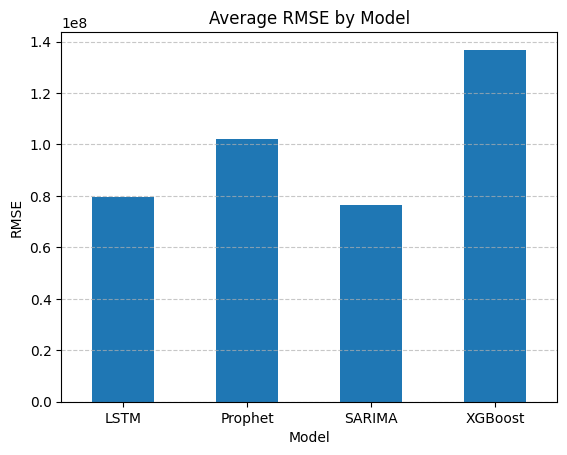

In [69]:
import matplotlib.pyplot as plt

avg_rmse = results_df.groupby('Model')['RMSE'].mean()

ax = avg_rmse.plot(kind='bar')

plt.title("Average RMSE by Model")
plt.ylabel("RMSE")
plt.xticks(rotation=0)

# add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Best model count (per state)

In [63]:
best_models = results_df.loc[
    results_df.groupby('State')['RMSE'].idxmin()
].reset_index(drop=True)

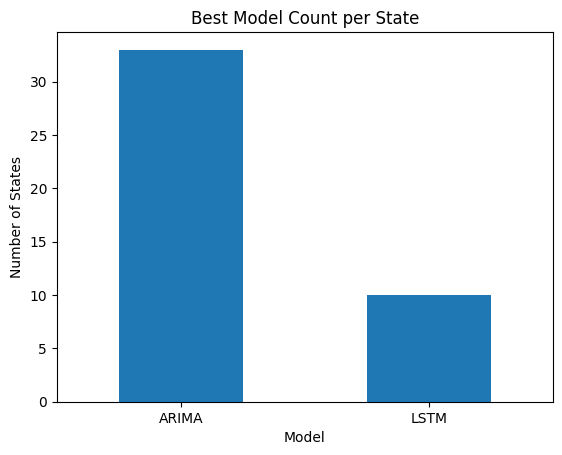

In [64]:
best_models['Model'].value_counts().plot(kind='bar')

plt.title("Best Model Count per State")
plt.ylabel("Number of States")
plt.xticks(rotation=0)
plt.show()

## Model Comparison Observations

- SARIMA achieved the lowest average RMSE, indicating best overall performance.
- ARIMA was selected as the best model for the highest number of states.
- LSTM showed competitive performance for a few states.
- Prophet and XGBoost performed relatively weaker on this dataset.
- Model performance varies across states, indicating no single model is universally best.

## Conclusion

- Per-state model selection was used instead of choosing one global model.
- This ensures optimal performance for each state individually.

## Note on Fine-Tuning

- In this assignment, default/basic configurations were used as per given constraints.
- No extensive hyperparameter tuning was performed.

## Possible Fine-Tuning Approaches (Future Scope)

- **SARIMA**: Grid search over (p,d,q) and seasonal parameters.
- **Prophet**: Tune changepoint_prior_scale, seasonality, and add holidays.
- **XGBoost**: Tune n_estimators, max_depth, learning_rate using cross-validation.
- **LSTM**: Adjust sequence length, number of layers, neurons, and epochs.

- Fine-tuning can improve model accuracy but was intentionally avoided to maintain fairness and consistency across models.

**Saving the best model**

In [71]:
import os
import pickle

In [72]:
os.makedirs("models", exist_ok=True)

for state in train_df['State'].unique():

    # get full data for the state (train + val if you want max data)
    data = df[df['State'] == state].sort_values('Date')

    # set proper datetime index
    data = data.set_index('Date')
    data.index = pd.DatetimeIndex(data.index, freq='W')

    # target
    y = data['Total']

    # train SARIMA
    model = SARIMAX(
        y,
        order=(1,1,1),
        seasonal_order=(1,1,1,52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    # save model
    with open(f"models/{state}_sarima.pkl", "wb") as f:
        pickle.dump(model_fit, f)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

In [73]:
import os
print(os.listdir("models"))

['Missouri_sarima.pkl', 'Maine_sarima.pkl', 'Kentucky_sarima.pkl', 'Minnesota_sarima.pkl', 'Michigan_sarima.pkl', 'California_sarima.pkl', 'Florida_sarima.pkl', 'Colorado_sarima.pkl', 'Indiana_sarima.pkl', 'Oregon_sarima.pkl', 'South Carolina_sarima.pkl', 'Utah_sarima.pkl', 'Ohio_sarima.pkl', 'Arkansas_sarima.pkl', 'Nevada_sarima.pkl', 'Oklahoma_sarima.pkl', 'Wyoming_sarima.pkl', 'Iowa_sarima.pkl', 'Nebraska_sarima.pkl', 'Vermont_sarima.pkl', 'Pennsylvania_sarima.pkl', 'Maryland_sarima.pkl', 'Tennessee_sarima.pkl', 'North Carolina_sarima.pkl', 'Virginia_sarima.pkl', 'Kansas_sarima.pkl', 'South Dakota_sarima.pkl', 'Massachusetts_sarima.pkl', 'Arizona_sarima.pkl', 'Wisconsin_sarima.pkl', 'Louisiana_sarima.pkl', 'Georgia_sarima.pkl', 'Illinois_sarima.pkl', 'New Hampshire_sarima.pkl', 'Rhode Island_sarima.pkl', 'New Mexico_sarima.pkl', 'Texas_sarima.pkl', 'West Virginia_sarima.pkl', 'Mississippi_sarima.pkl', 'Connecticut_sarima.pkl', 'Washington_sarima.pkl', 'Alabama_sarima.pkl', 'New York

In [74]:
import shutil

shutil.make_archive("models", 'zip', "models")

'/content/models.zip'

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [78]:
import shutil

shutil.copytree("models", "/content/drive/MyDrive/models")

'/content/drive/MyDrive/models'